# Project 2 - Autoregressive forecast with autocorrelated loads for a 10 port network

<b>Import Python Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from statsmodels.graphics.tsaplots import plot_acf

<b>Parameters

In [27]:
networkFactor = 100    # To change the characteristics of the network (Y)
cosPhi=0.95            # Value of teta
time=24                # Training Period  
timeForecast=12        # Test Period

lag_pv=0.95
lag_load=0.75

error_load=0.25
error_pv=0.5

<b>Import data (From Excel file)

In [28]:
Info = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Info', header=None))
# Information about the slack bus
SlackBus=Info[0,1]
print ("Slack Bus: ", SlackBus,"\n")

# Network Information
Net_Info = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Y_Data'))
print ("Lines information (Admitances)\n", Net_Info, "\n")

#Power Information (Train)
Power_Info = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Load(t,Bus)'))
Power_Info = np.delete(Power_Info,[0],1)
print ("Power consumption information (time, Bus)\n", Power_Info, "\n")

#Power Information (Test)
Power_Test = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Test_Load(t,Bus)'))
Power_Test = np.delete(Power_Test,[0],1)
print ("Power consumption information (time, Bus)\n", Power_Test, "\n")

P = np.dot(-Power_Info, np.exp(complex(0,1)*np.arccos(cosPhi)))  # shape (13, 9)
I = np.conj(P[0, :])   # row 0 = first time step, all 9 buses → shape (9,)


Slack Bus:  1 

Lines information (Admitances)
 [[1 2 '0,01-0,10i']
 [2 3 '0,02-0,15i']
 [3 4 '0,02-0,15i']
 [4 5 '0,03-0,20i']
 [2 6 '0,02-0,18i']
 [3 6 '0,03-0,22i']
 [3 7 '0,03-0,22i']
 [4 7 '0,02-0,18i']
 [6 8 '0,04-0,25i']
 [7 9 '0,04-0,25i']
 [8 10 '0,05-0,30i']
 [9 10 '0,05-0,30i']] 

Power consumption information (time, Bus)
 [[0.5   0.8   0.6   0.3   0.7   0.4   0.5   0.4   0.3  ]
 [0.5   0.707 0.568 0.329 0.298 0.603 0.463 0.439 0.287]
 [0.404 0.324 0.414 0.287 0.165 0.394 0.445 0.375 0.295]
 [0.44  0.366 0.23  0.217 0.068 0.267 0.276 0.493 0.348]
 [0.603 0.167 0.305 0.193 0.03  0.239 0.27  0.387 0.391]
 [0.477 0.072 0.445 0.03  0.03  0.142 0.273 0.656 0.208]
 [0.371 0.03  0.546 0.03  0.11  0.03  0.125 0.632 0.092]
 [0.552 0.47  0.313 0.058 0.49  0.034 0.386 0.435 0.125]
 [0.584 0.396 0.21  0.182 0.453 0.03  0.399 0.241 0.152]
 [0.426 0.083 0.239 0.108 0.439 0.082 0.161 0.263 0.176]
 [0.444 0.268 0.378 0.03  0.358 0.03  0.235 0.197 0.496]
 [0.308 0.03  0.235 0.03  0.03  0.211

<b>Admittance Matrix(<i>Y</i>); Conductance Matrix(<i>G</i>); Susceptance Matrix(<i>B</i>)

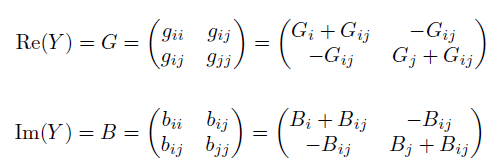

In [29]:
# Determine the number of Bus
nBus=max(np.max(Net_Info[:,0]),np.max(Net_Info[:,1]))

# Create the variable number of lines and the admitance matrix (Y)
nLines=Net_Info.shape[0]

Y=np.zeros((nBus,nBus), dtype=complex)

#Complete the Y matrix nad update the number of lines
for i in range (Net_Info.shape[0]):
    y_aux=Net_Info[i,2].replace(",",".")
    y_aux=y_aux.replace("i","j")
    Y[Net_Info[i,0]-1,Net_Info[i,0]-1]=Y[Net_Info[i,0]-1,Net_Info[i,0]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,1]-1]=Y[Net_Info[i,1]-1,Net_Info[i,1]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,0]-1,Net_Info[i,1]-1]=Y[Net_Info[i,0]-1,Net_Info[i,1]-1]-complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,0]-1]=Y[Net_Info[i,1]-1,Net_Info[i,0]-1]-complex(y_aux)*networkFactor

            
# Remove the slack bus from the admitance matrix            
Yl=np.delete(Y, np.s_[SlackBus-1], axis=0)
Yl=np.delete(Yl, np.s_[SlackBus-1], axis=1)

# Conductance Matrix
G=Yl.real

# Susceptance Matrix
B=Yl.imag 

print("The admitance matrix Y is:\n", Y, "\n")
print("The conductance matrix G is\n", G, "\n")
print("The susceptance matrix B is\n",B, "\n")

The admitance matrix Y is:
 [[ 1.-10.j -1.+10.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
   0. +0.j  0. +0.j]
 [-1.+10.j  5.-43.j -2.+15.j  0. +0.j  0. +0.j -2.+18.j  0. +0.j  0. +0.j
   0. +0.j  0. +0.j]
 [ 0. +0.j -2.+15.j 10.-74.j -2.+15.j  0. +0.j -3.+22.j -3.+22.j  0. +0.j
   0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j -2.+15.j  7.-53.j -3.+20.j  0. +0.j -2.+18.j  0. +0.j
   0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j -3.+20.j  3.-20.j  0. +0.j  0. +0.j  0. +0.j
   0. +0.j  0. +0.j]
 [ 0. +0.j -2.+18.j -3.+22.j  0. +0.j  0. +0.j  9.-65.j  0. +0.j -4.+25.j
   0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j -3.+22.j -2.+18.j  0. +0.j  0. +0.j  9.-65.j  0. +0.j
  -4.+25.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -4.+25.j  0. +0.j  9.-55.j
   0. +0.j -5.+30.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -4.+25.j  0. +0.j
   9.-55.j -5.+30.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -5.+30.j
  -5.+30.j 10.-60.j]] 

The conductance mat

<b> Errors Definition

Random values considering a normal distribution

In [30]:
np.random.seed(50)
e1=np.random.randn(time+timeForecast)*error_pv  #Errors associated to Wind Generation
e  = np.random.randn(nBus-1, time+timeForecast) * error_load  # ← shape (9, 36): one noise series per bus
e2 = np.random.randn(time+timeForecast)*error_pv #Errors associated to Power Injection (Consumption) in the test period

<b> Determine the solar generation and the load flow in all nodes

In [31]:

#Creation of Matrix
II = np.zeros((nBus-1, time+timeForecast), dtype=complex)
lines = [
    (1,2),(2,3),(3,4),(4,5),
    (2,6),(3,6),(3,7),(4,7),
    (6,8),(7,9),(8,10),(9,10)
]
I_lines = np.zeros((len(lines), time+timeForecast))
i_pv1   = np.zeros(time+timeForecast)   # PV source at Bus 5 (index 3 after slack removed)
i_pv2   = np.zeros(time+timeForecast)   # PV source at Bus 7 (index 5 after slack removed)

# Initializing the process of data generation
II[:,0]=I                                      #Power Injections
v = 1+np.dot(np.linalg.inv(Yl),I)
v_full = np.insert(v, SlackBus-1, 1.0+0j)          # reinsert slack bus voltage
i_pv1[0] = np.real(I[3])                            # Bus 5 is index 3 (slack Bus 1 removed)
i_pv2[0] = np.real(I[5])                            # Bus 7 is index 5
for k, (bi, bj) in enumerate(lines):
    I_flow = -Y[bi-1, bj-1] * (v_full[bi-1] - v_full[bj-1])
    I_lines[k, 0] = np.absolute(I_flow) * np.sign(np.real(I_flow))

# Process of data generation
for t in range(time+timeForecast-1):             

    II[:, t+1]  = lag_load*II[:, t] + e[:, t]  # Power injection process with noise

    # CORRELATION LINES
    i_pv1[t+1]    = lag_pv*i_pv1[t] + e1[t]  # PV1 process with noise
    i_pv2[t+1]    = lag_pv*i_pv2[t] + e2[t]  # PV2 process with noise


    II[3,t+1] = i_pv1[t+1]+complex(0,np.imag(II[3,t+1]))   # Bus 5 injection
    II[5,t+1] = i_pv2[t+1]+complex(0,np.imag(II[5,t+1]))   # Bus 7 injection
    v      = 1+np.dot(np.linalg.inv(Yl),II[:,t+1])
    v_full = np.insert(v, SlackBus-1, 1.0+0j)
    for k, (bi, bj) in enumerate(lines):
        I_flow = -Y[bi-1, bj-1] * (v_full[bi-1] - v_full[bj-1])
        I_lines[k, t+1] = np.absolute(I_flow) * np.sign(np.real(I_flow))

    
print('The power injection in Bus 5 (PV1) is:\n', i_pv1)
print('The power injection in Bus 7 (PV2) is:\n', i_pv2)
for k, (bi, bj) in enumerate(lines):
    print(f'Power flow in Line {bi}-{bj}:\n', I_lines[k,:])

The power injection in Bus 5 (PV1) is:
 [-0.285      -1.05092605 -1.01386855 -1.27363934 -1.94224761 -1.13916217
 -1.32057013 -1.64477624 -1.02740356 -1.61717968 -2.20006014 -2.02688832
 -1.49444704 -1.07135621 -1.18507099 -1.62458047 -0.7438973   0.95033524
  1.3967037   1.38880165  1.69075426  1.40923862  1.4128346   1.13607564
  0.99891433  1.01873435  1.11053232  0.91437471  1.72410963  1.56302083
  1.83002315  2.28612675  2.84102476  2.01448269  2.15697237  2.42588459]
The power injection in Bus 7 (PV2) is:
 [-0.38        0.1747145   0.50187657  0.22018843 -0.44714686 -0.71306341
 -0.59014586  0.37060116  0.01294549 -0.37815298 -0.11432818  0.04305354
 -0.28847153 -0.53782929 -0.46499472  0.28025159 -0.52169286 -0.62659526
 -0.55367515 -0.04802667 -0.10170002  0.48071219  0.46432387  1.25631038
  0.54027371  0.40098743  0.09412999  0.14176986 -0.10568899  0.36688507
  0.43749317 -0.02627631 -0.04397764  0.37963395  0.65090639  0.94154984]
Power flow in Line 1-2:
 [ 4.5         4.0

<b>Ordinary Least Squares OLS regression
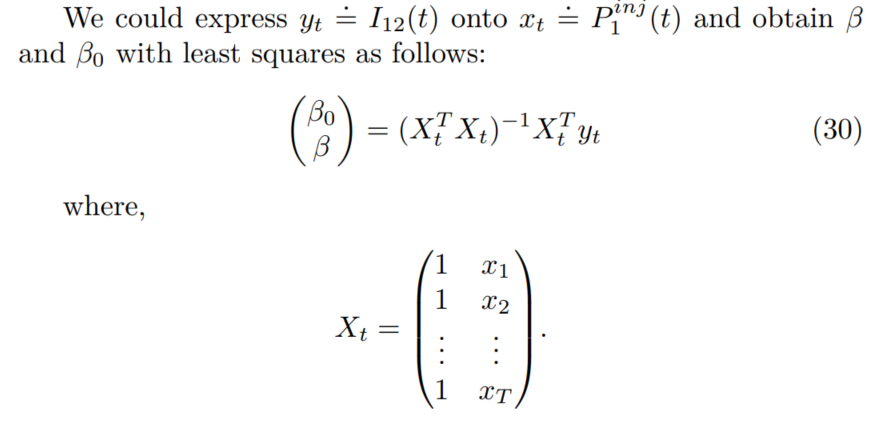

<b>Durbin-Watson statistic
    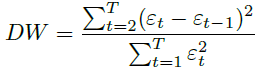

<b>Cochrane Orcutt
   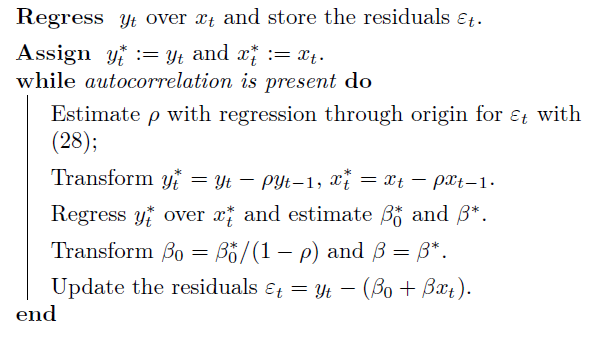

<b>Autocorrelation Method 
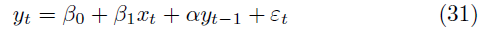
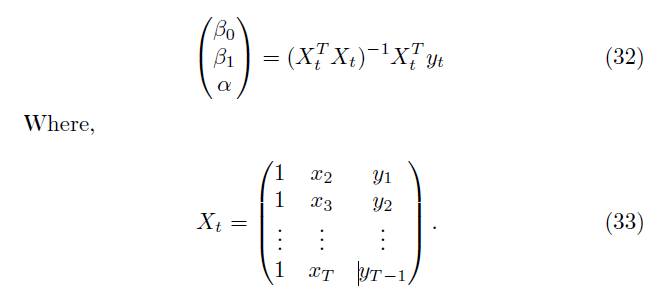

<b> Models
- 1 - OLS 
- 2 - Cochrane Orcutt (CO)
- 3 - Autorregration AR(1) 
- 4 - Autorregration with Loads AR(1)+Load Sum

## Solvers

In [32]:
nL = len(lines)

# Storage for betas and residuals across all lines and methods
beta_OLS     = np.zeros((nL, 3))        # intercept + pv1 + pv2
beta_CO_all  = np.zeros((nL, 3))
beta_AR1_all = np.zeros((nL, 4))        # intercept + pv1 + pv2 + lagged line current
beta_AR1L_all= np.zeros((nL, 5))        # intercept + pv1 + pv2 + lagged + load sum

resid_OLS    = np.zeros((nL, timeForecast))
resid_CO     = np.zeros((nL, timeForecast))
resid_AR1    = np.zeros((nL, timeForecast-1))
resid_AR1L   = np.zeros((nL, timeForecast-1))

DW_OLS  = np.zeros(nL)
DW_CO   = np.zeros(nL)
DW_AR1  = np.zeros(nL)
DW_AR1L = np.zeros(nL)

In [33]:
# Load sum regressor: sum of real power injections across all non-PV, non-slack buses
# (buses 2,3,4,6,8,9,10 → indices 1,2,3,5,7,8 in II after slack removed)
load_indices = [0, 1, 2, 4, 6, 7, 8]
load_sum = np.sum(np.real(II[load_indices, :]), axis=0)  # shape (time+timeForecast,)

for k, (bi, bj) in enumerate(lines):
    iL = I_lines[k, :]   # current in line k, full time series

    # ── 1. OLS ───────────────────────────────────────────────────────────────
    Xt = np.ones((time, 3))
    Xt[:, 1] = i_pv1[0:time]
    Xt[:, 2] = i_pv2[0:time]
    XtT = np.transpose(Xt)
    b = np.dot(np.dot(np.linalg.inv(np.dot(XtT, Xt)), XtT), iL[0:time])
    beta_OLS[k] = b

    epsilon = iL[0:time] - (b[0] + b[1]*i_pv1[0:time] + b[2]*i_pv2[0:time])
    dw1 = np.sum((epsilon[1:time-1] - epsilon[0:time-2])**2)
    dw2 = np.sum((epsilon[0:time-2])**2)
    DW_OLS[k] = np.divide(dw1, dw2)

    iL_out_OLS = b[0] + b[1]*i_pv1[time:time+timeForecast] + b[2]*i_pv2[time:time+timeForecast]
    resid_OLS[k] = iL[time:time+timeForecast] - iL_out_OLS

    # ── 2. Cochrane-Orcutt ───────────────────────────────────────────────────
    res_1 = iL[0:time] - (b[0] + b[1]*i_pv1[0:time] + b[2]*i_pv2[0:time])
    for _ in range(3):
        r2 = res_1[0:time-1]
        r1 = res_1[1:time]
        ro = np.dot(r2, r1) / np.dot(r2, r2)

        iL_s   = iL[1:time]   - ro*iL[0:time-1]
        pv1_s  = i_pv1[1:time] - ro*i_pv1[0:time-1]
        pv2_s  = i_pv2[1:time] - ro*i_pv2[0:time-1]

        B_co = np.ones((time-1, 3))
        B_co[:, 1] = pv1_s
        B_co[:, 2] = pv2_s
        BtB = np.dot(np.transpose(B_co), B_co)
        b_s = np.dot(np.dot(np.linalg.inv(BtB), np.transpose(B_co)), iL_s)
        b_s[0] = b_s[0] / (1 - ro)

        res_2 = iL[0:time] - (b_s[0] + b_s[1]*i_pv1[0:time] + b_s[2]*i_pv2[0:time])
        res_1 = res_2[:]
    beta_CO_all[k] = b_s

    epsilon = iL[0:time] - (b_s[0] + b_s[1]*i_pv1[0:time] + b_s[2]*i_pv2[0:time])
    dw1 = np.sum((epsilon[1:time-1] - epsilon[0:time-2])**2)
    dw2 = np.sum((epsilon[0:time-2])**2)
    DW_CO[k] = np.divide(dw1, dw2)

    iL_out_CO = b_s[0] + b_s[1]*i_pv1[time:time+timeForecast] + b_s[2]*i_pv2[time:time+timeForecast]
    resid_CO[k] = iL[time:time+timeForecast] - iL_out_CO

    # ── 3. AR(1) ─────────────────────────────────────────────────────────────
    Xt_AR = np.ones((time-1, 4))
    Xt_AR[:, 1] = i_pv1[1:time]
    Xt_AR[:, 2] = i_pv2[1:time]
    Xt_AR[:, 3] = iL[0:time-1]          # lagged line current
    XtT_AR = np.transpose(Xt_AR)
    b_AR = np.dot(np.dot(np.linalg.inv(np.dot(XtT_AR, Xt_AR)), XtT_AR), iL[1:time])
    beta_AR1_all[k] = b_AR

    epsilon = iL[1:time] - (b_AR[0] + b_AR[1]*i_pv1[1:time] + b_AR[2]*i_pv2[1:time] + b_AR[3]*iL[0:time-1])
    dw1 = np.sum((epsilon[1:time-1] - epsilon[0:time-2])**2)
    dw2 = np.sum((epsilon[0:time-2])**2)
    DW_AR1[k] = np.divide(dw1, dw2)

    iL_out_AR1 = (b_AR[0] + b_AR[1]*i_pv1[time+1:time+timeForecast]
                           + b_AR[2]*i_pv2[time+1:time+timeForecast]
                           + b_AR[3]*iL[time:time+timeForecast-1])
    resid_AR1[k] = iL[time+1:time+timeForecast] - iL_out_AR1

    # ── 4. AR(1) + Load Sum ──────────────────────────────────────────────────
    Xt_ARL = np.ones((time-1, 5))
    Xt_ARL[:, 1] = i_pv1[1:time]
    Xt_ARL[:, 2] = i_pv2[1:time]
    Xt_ARL[:, 3] = iL[0:time-1]
    Xt_ARL[:, 4] = load_sum[1:time]
    XtT_ARL = np.transpose(Xt_ARL)
    b_ARL = np.dot(np.dot(np.linalg.inv(np.dot(XtT_ARL, Xt_ARL)), XtT_ARL), iL[1:time])
    beta_AR1L_all[k] = b_ARL

    epsilon = (iL[1:time] - (b_ARL[0] + b_ARL[1]*i_pv1[1:time] + b_ARL[2]*i_pv2[1:time]
                             + b_ARL[3]*iL[0:time-1] + b_ARL[4]*load_sum[1:time]))
    dw1 = np.sum((epsilon[1:time-1] - epsilon[0:time-2])**2)
    dw2 = np.sum((epsilon[0:time-2])**2)
    DW_AR1L[k] = np.divide(dw1, dw2)

    iL_out_ARL = (b_ARL[0] + b_ARL[1]*i_pv1[time+1:time+timeForecast]
                            + b_ARL[2]*i_pv2[time+1:time+timeForecast]
                            + b_ARL[3]*iL[time:time+timeForecast-1]
                            + b_ARL[4]*load_sum[time+1:time+timeForecast])
    resid_AR1L[k] = iL[time+1:time+timeForecast] - iL_out_ARL

# ── Summary print ─────────────────────────────────────────────────────────────
for k, (bi, bj) in enumerate(lines):
    print(f"\nLine {bi}-{bj}:")
    print(f"  OLS  betas={np.round(beta_OLS[k],4)}  DW={DW_OLS[k]:.4f}")
    print(f"  CO   betas={np.round(beta_CO_all[k],4)}  DW={DW_CO[k]:.4f}")
    print(f"  AR1  betas={np.round(beta_AR1_all[k],4)}  DW={DW_AR1[k]:.4f}")
    print(f"  AR1L betas={np.round(beta_AR1L_all[k],4)}  DW={DW_AR1L[k]:.4f}")


Line 1-2:
  OLS  betas=[ 0.8606 -1.4486 -0.8623]  DW=0.5520
  CO   betas=[ 0.5553 -1.3394 -1.0237]  DW=0.4460
  AR1  betas=[ 0.2208 -0.8791 -0.4105  0.4511]  DW=1.5268
  AR1L betas=[-0.0085 -0.9813 -0.9648  0.019  -1.004 ]  DW=0.3903

Line 2-3:
  OLS  betas=[ 0.4477 -0.7005 -0.4725]  DW=0.6259
  CO   betas=[ 0.3271 -0.6497 -0.5257]  DW=0.5219
  AR1  betas=[ 0.1324 -0.4325 -0.2415  0.4477]  DW=1.5484
  AR1L betas=[ 0.0459 -0.4702 -0.5218  0.0432 -0.4561]  DW=2.1162

Line 3-4:
  OLS  betas=[ 0.2224 -0.6843  0.041 ]  DW=0.9593
  CO   betas=[ 0.216  -0.627  -0.0891]  DW=0.5338
  AR1  betas=[ 0.1978 -0.6659  0.0706  0.0367]  DW=1.1214
  AR1L betas=[ 0.1273 -0.624   0.0355  0.024  -0.1041]  DW=1.3956

Line 4-5:
  OLS  betas=[ 8.000e-04 -9.999e-01 -6.000e-04]  DW=0.7177
  CO   betas=[ 1.e-04 -1.e+00  1.e-04]  DW=0.7132
  AR1  betas=[ 2.0000e-04 -1.0002e+00  2.0000e-04 -2.0000e-04]  DW=0.4323
  AR1L betas=[ 0.e+00 -1.e+00  2.e-04 -1.e-04 -3.e-04]  DW=0.3880

Line 2-6:
  OLS  betas=[ 0.3837 -0

In [34]:
# Check residual autocorrelation for line 0 (Bus 1-2) after OLS fit
k = 0
iL = I_lines[k, :]
b  = beta_OLS[k]
fitted    = b[0] + b[1]*i_pv1[0:time] + b[2]*i_pv2[0:time]
residuals = iL[0:time] - fitted

# Lag-1 autocorrelation
r0 = residuals - np.mean(residuals)
ac = np.dot(r0[1:], r0[:-1]) / np.dot(r0, r0)
print(f"Lag-1 residual autocorrelation: {ac:.4f}")
print(f"DW statistic: {DW_OLS[k]:.4f}  (expect ~2*(1-ac))")

Lag-1 residual autocorrelation: 0.5519
DW statistic: 0.5520  (expect ~2*(1-ac))


In [35]:
for k, (bi, bj) in enumerate(lines):
    iL = I_lines[k, :]
    b  = beta_OLS[k]
    fitted    = b[0] + b[1]*i_pv1[0:time] + b[2]*i_pv2[0:time]
    residuals = iL[0:time] - fitted
    r0 = residuals - np.mean(residuals)
    ac = np.dot(r0[1:], r0[:-1]) / np.dot(r0, r0)
    print(f"Line {bi}-{bj}: lag-1 autocorr = {ac:.4f},  DW = {DW_OLS[k]:.4f}")

Line 1-2: lag-1 autocorr = 0.5519,  DW = 0.5520
Line 2-3: lag-1 autocorr = 0.5529,  DW = 0.6259
Line 3-4: lag-1 autocorr = 0.4539,  DW = 0.9593
Line 4-5: lag-1 autocorr = 0.1865,  DW = 0.7177
Line 2-6: lag-1 autocorr = 0.5302,  DW = 0.6185
Line 3-6: lag-1 autocorr = 0.6189,  DW = 0.7684
Line 3-7: lag-1 autocorr = 0.6321,  DW = 0.5675
Line 4-7: lag-1 autocorr = 0.2879,  DW = 1.4407
Line 6-8: lag-1 autocorr = 0.5485,  DW = 0.6991
Line 7-9: lag-1 autocorr = 0.6133,  DW = 0.6732
Line 8-10: lag-1 autocorr = 0.3917,  DW = 1.1946
Line 9-10: lag-1 autocorr = 0.2029,  DW = 1.5150


In [36]:
import numpy as np
from tabulate import tabulate

metrics = []
for k, (bi, bj) in enumerate(lines):
    iL = I_lines[k, :]
    real_AR  = iL[time+1:time+timeForecast]   # length 11 (AR methods)
    real_OLS = iL[time:time+timeForecast]      # length 12 (OLS/CO methods)

    b_OLS = beta_OLS[k]
    b_CO  = beta_CO_all[k]
    b_AR1 = beta_AR1_all[k]
    b_ARL = beta_AR1L_all[k]

    # Forecast calculations
    fc_OLS = b_OLS[0] + b_OLS[1]*i_pv1[time:time+timeForecast] + b_OLS[2]*i_pv2[time:time+timeForecast]
    fc_CO  = b_CO[0]  + b_CO[1]*i_pv1[time:time+timeForecast]  + b_CO[2]*i_pv2[time:time+timeForecast]
    fc_AR1 = (b_AR1[0] + b_AR1[1]*i_pv1[time+1:time+timeForecast]
                       + b_AR1[2]*i_pv2[time+1:time+timeForecast]
                       + b_AR1[3]*iL[time:time+timeForecast-1])
    fc_ARL = (b_ARL[0] + b_ARL[1]*i_pv1[time+1:time+timeForecast]
                       + b_ARL[2]*i_pv2[time+1:time+timeForecast]
                       + b_ARL[3]*iL[time:time+timeForecast-1]
                       + b_ARL[4]*load_sum[time+1:time+timeForecast])

    # Metric functions
    def mae(real, fc): return np.mean(np.abs(real - fc))
    def rmse(real, fc): return np.sqrt(np.mean((real - fc)**2))
    def max_err(real, fc): return np.max(np.abs(real - fc)) # New metric

    metrics.append([
        f"{bi}-{bj}",
        f"{mae(real_OLS, fc_OLS):.4f}", f"{rmse(real_OLS, fc_OLS):.4f}", f"{max_err(real_OLS, fc_OLS):.4f}",
        f"{mae(real_OLS, fc_CO):.4f}",  f"{rmse(real_OLS, fc_CO):.4f}",  f"{max_err(real_OLS, fc_CO):.4f}",
        f"{mae(real_AR,  fc_AR1):.4f}", f"{rmse(real_AR,  fc_AR1):.4f}", f"{max_err(real_AR,  fc_AR1):.4f}",
        f"{mae(real_AR,  fc_ARL):.4f}", f"{rmse(real_AR,  fc_ARL):.4f}", f"{max_err(real_AR,  fc_ARL):.4f}",
    ])

# Expanded headers
headers = ["Line",
           "OLS MAE", "OLS RMSE", "OLS MAX",
           "CO MAE",  "CO RMSE",  "CO MAX",
           "AR1 MAE", "AR1 RMSE", "AR1 MAX",
           "ARL MAE", "ARL RMSE", "ARL MAX"]

print(tabulate(metrics, headers=headers, tablefmt="rounded_outline"))

# Overall average across all lines
arr = np.array([[float(v) for v in row[1:]] for row in metrics])
avg = np.mean(arr, axis=0)
print("\nAverage across all lines:")
print(tabulate([["AVG"] + [f"{v:.4f}" for v in avg]], headers=headers, tablefmt="rounded_outline"))

╭────────┬───────────┬────────────┬───────────┬──────────┬───────────┬──────────┬───────────┬────────────┬───────────┬───────────┬────────────┬───────────╮
│ Line   │   OLS MAE │   OLS RMSE │   OLS MAX │   CO MAE │   CO RMSE │   CO MAX │   AR1 MAE │   AR1 RMSE │   AR1 MAX │   ARL MAE │   ARL RMSE │   ARL MAX │
├────────┼───────────┼────────────┼───────────┼──────────┼───────────┼──────────┼───────────┼────────────┼───────────┼───────────┼────────────┼───────────┤
│ 1-2    │    0.4565 │     0.6126 │    1.3217 │   0.4439 │    0.5921 │   1.3097 │    0.4895 │     0.5967 │    1.3123 │    0.009  │     0.0106 │    0.0192 │
│ 2-3    │    0.2055 │     0.2524 │    0.4697 │   0.1751 │    0.2228 │   0.4424 │    0.1869 │     0.2214 │    0.4438 │    0.1622 │     0.1847 │    0.2872 │
│ 3-4    │    0.1416 │     0.1632 │    0.3092 │   0.1714 │    0.2042 │   0.3791 │    0.1372 │     0.1561 │    0.2788 │    0.1335 │     0.1561 │    0.2744 │
│ 4-5    │    0.0008 │     0.0008 │    0.0011 │   0.0001 │    0.

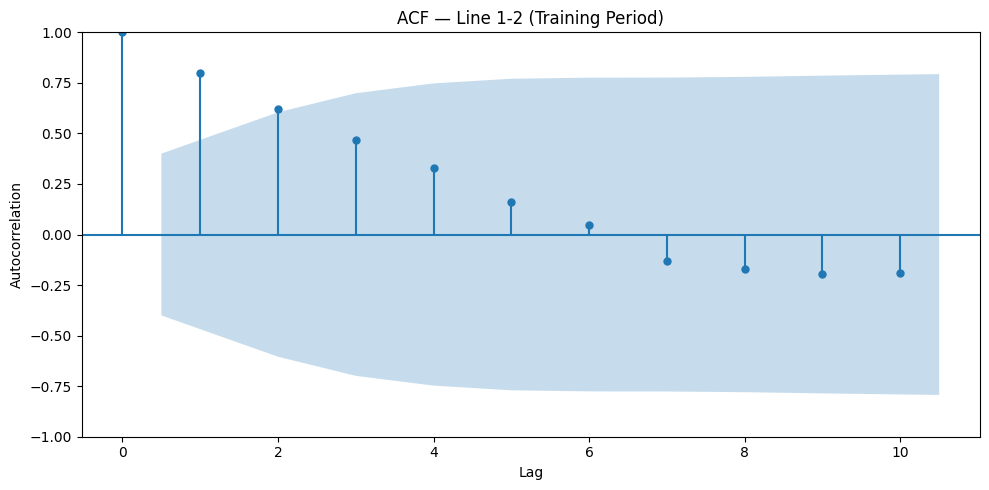

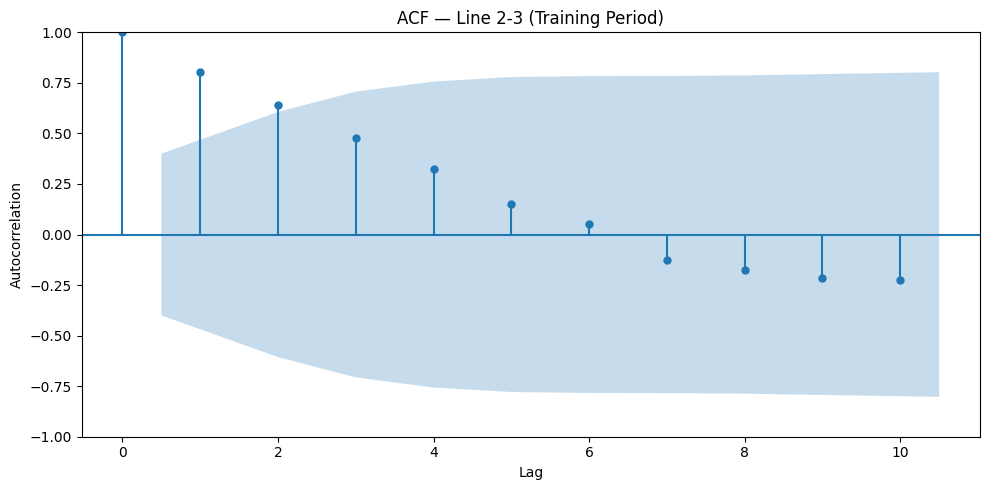

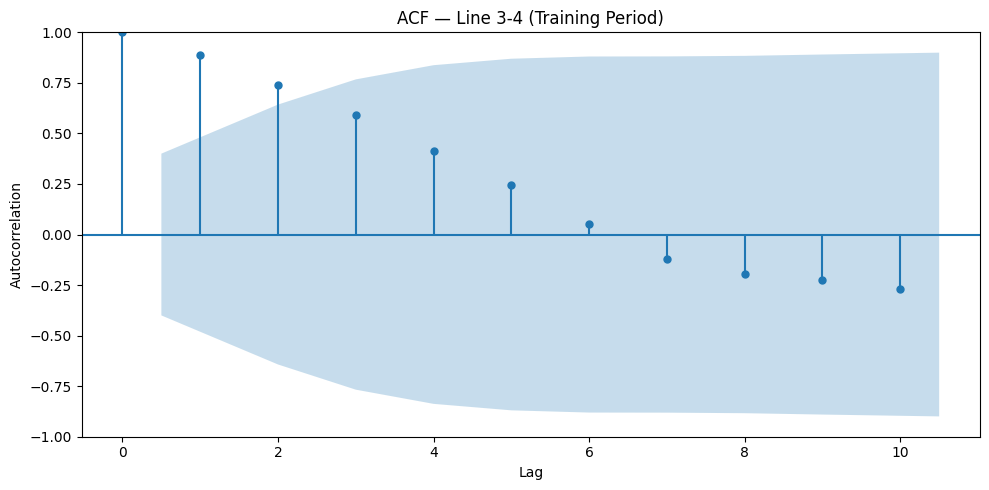

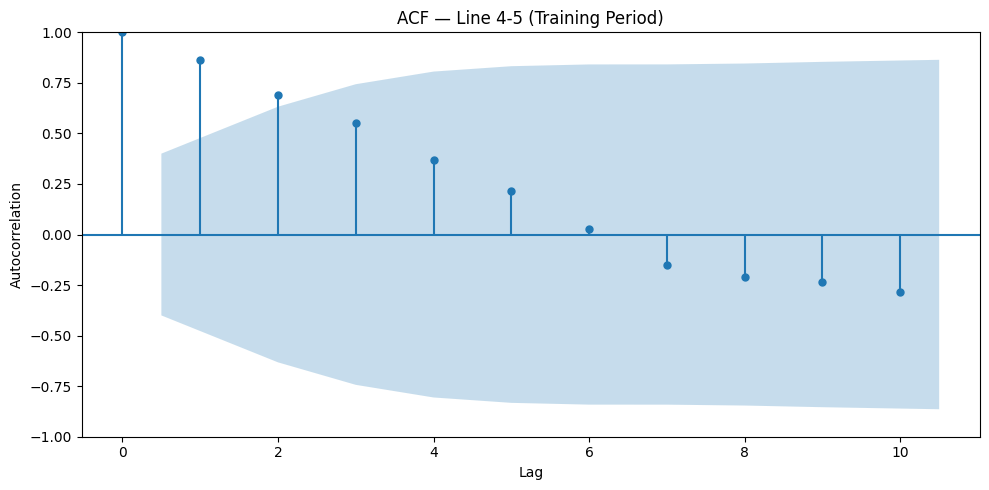

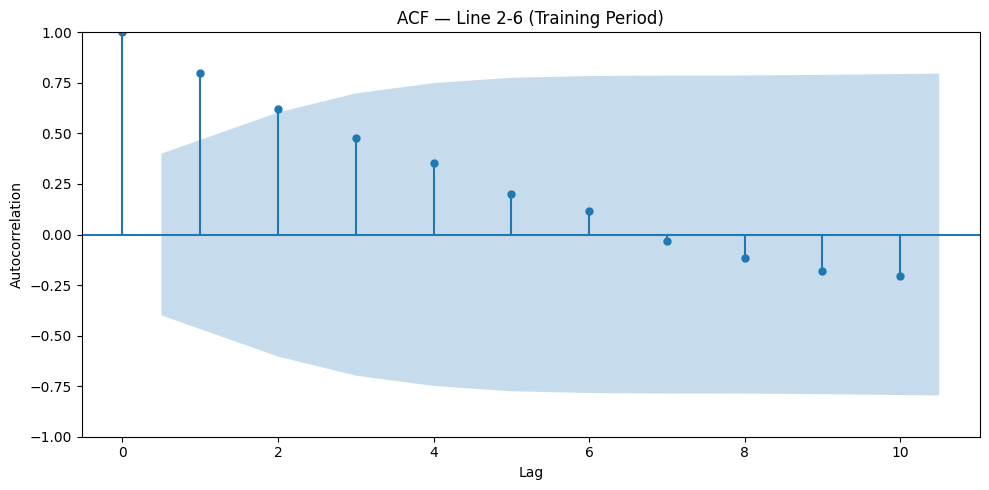

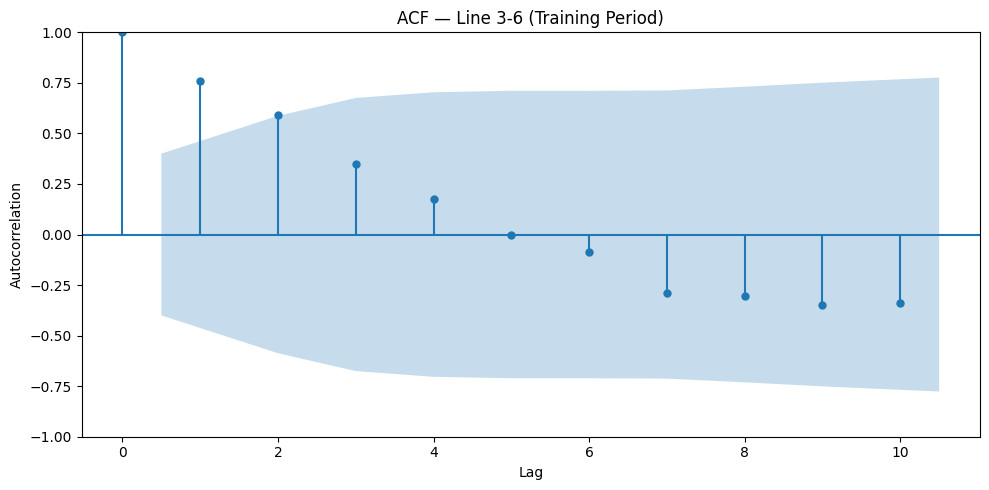

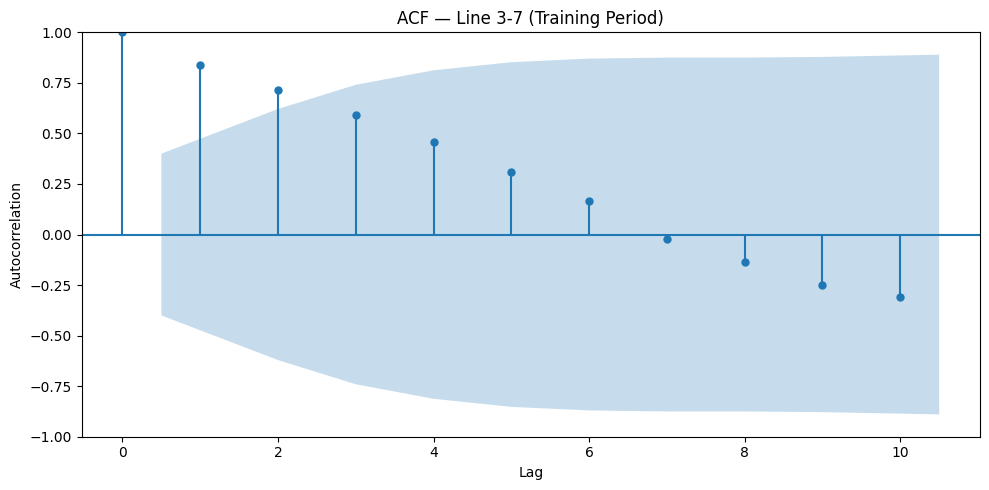

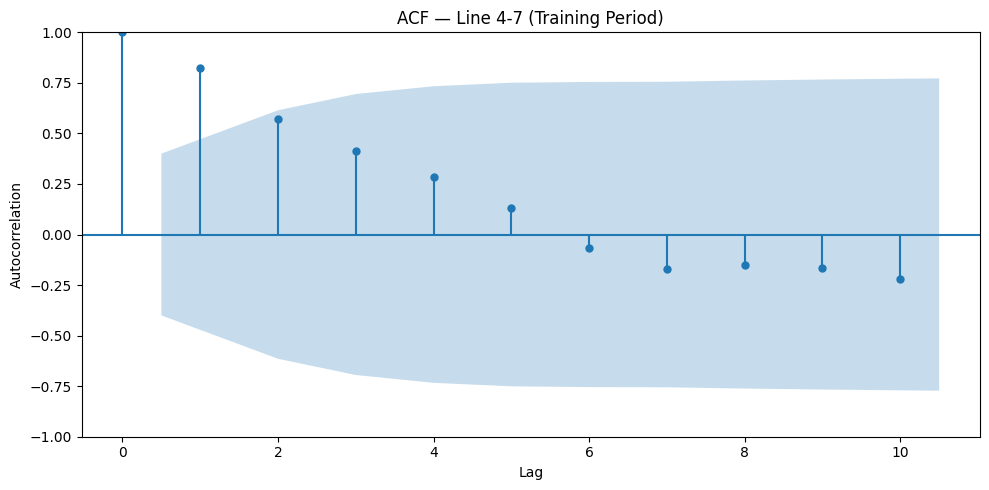

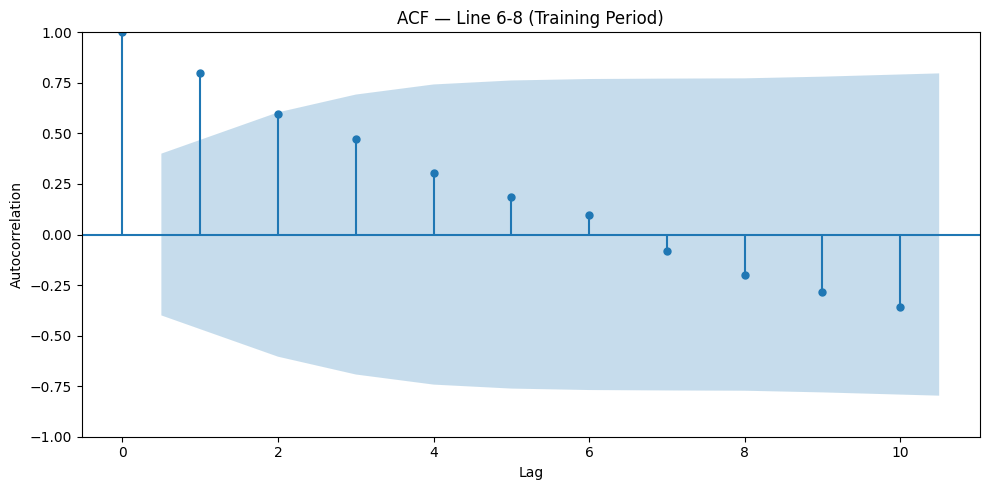

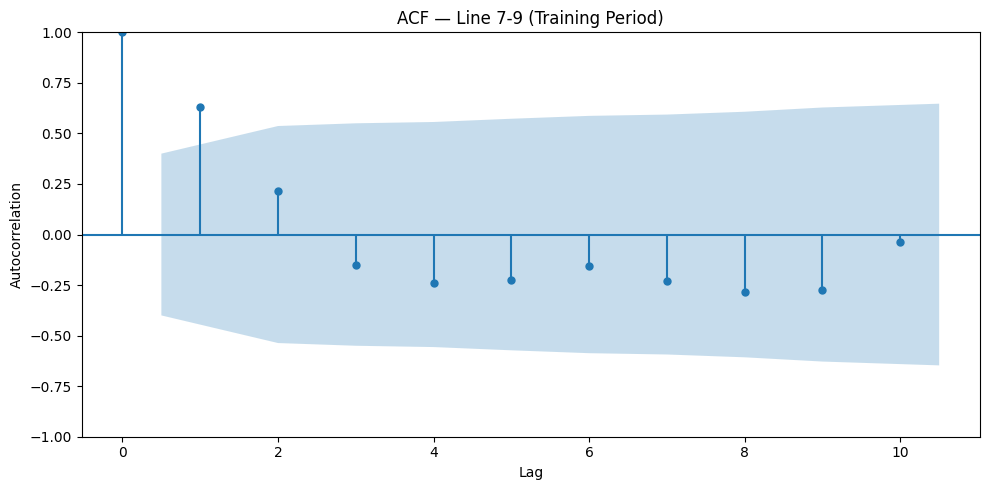

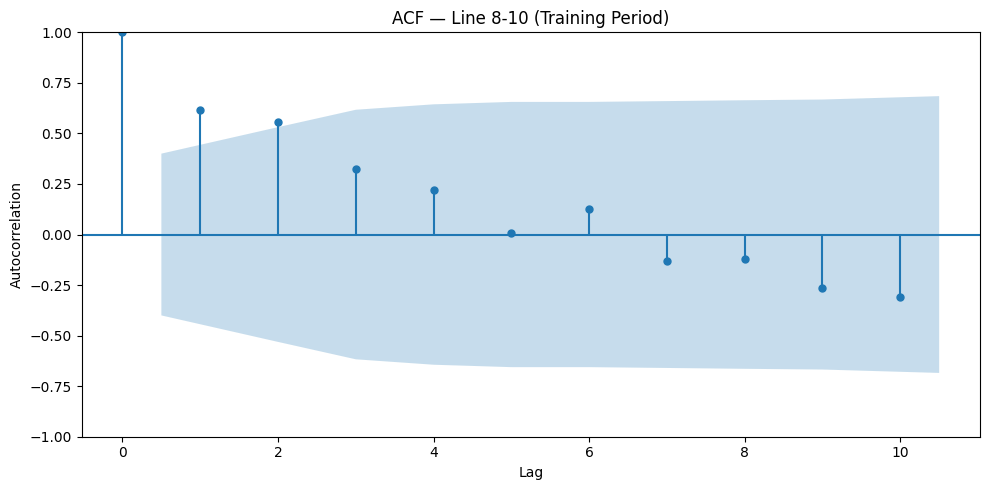

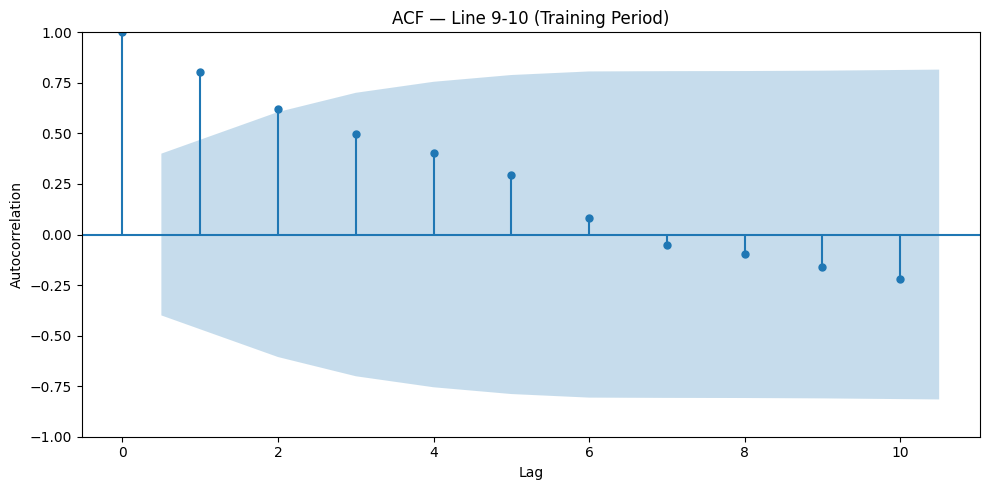

In [39]:
n_lags = 10  # how many lags to show

for k, (bi, bj) in enumerate(lines):
    # 1. Create a new figure and axis for every line
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # 2. Plot the ACF onto the specific axis 'ax'
    plot_acf(I_lines[k, :time], lags=n_lags, ax=ax, alpha=0.05)
    
    # 3. Style the individual plot
    ax.set_title(f"ACF — Line {bi}-{bj} (Training Period)")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    
    plt.tight_layout()
    
    # 4. Either show the plot or save it to a unique file
    plt.show() 


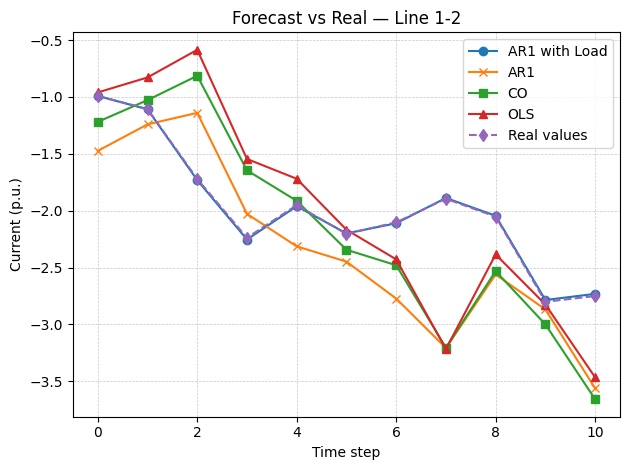

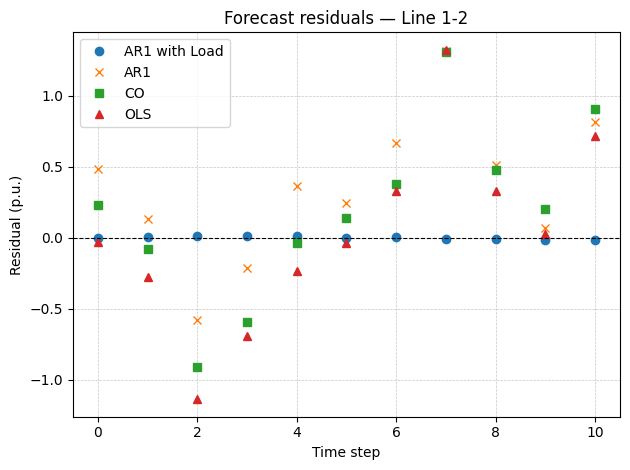

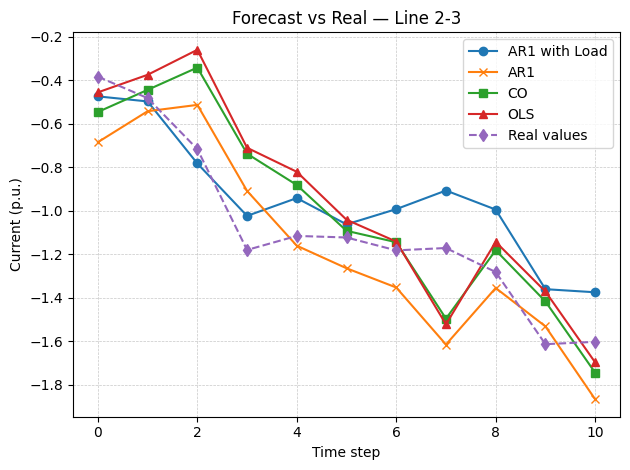

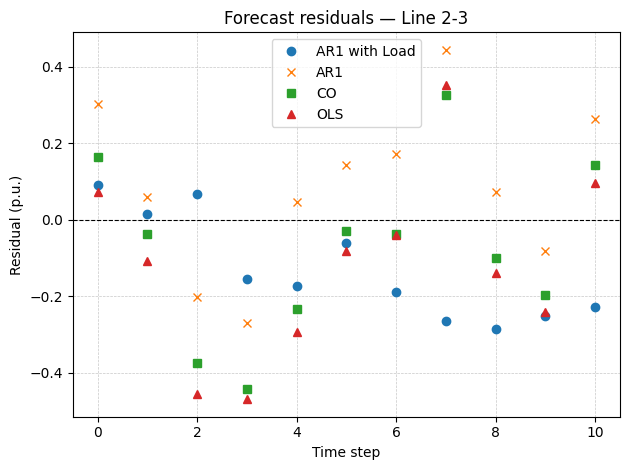

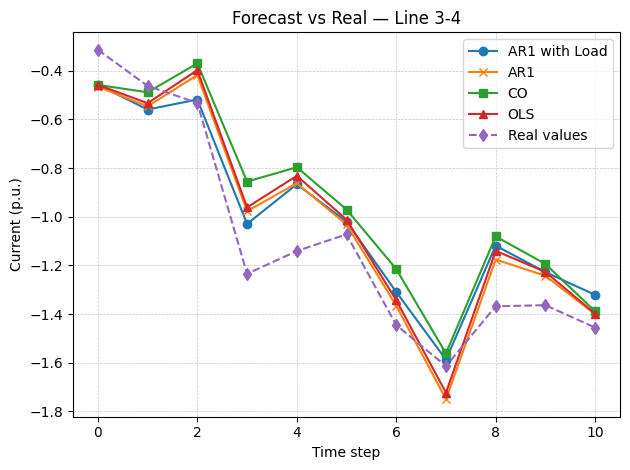

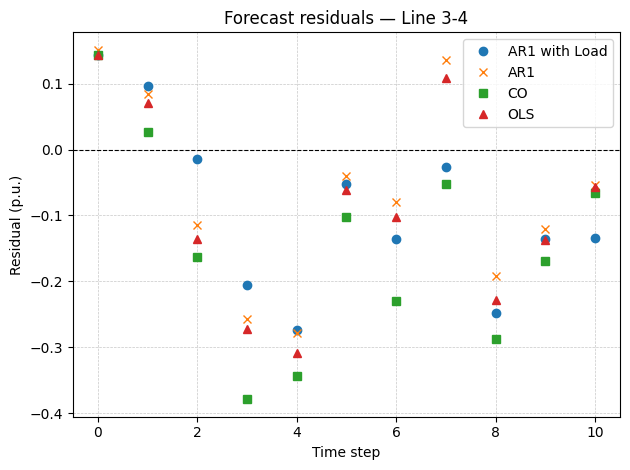

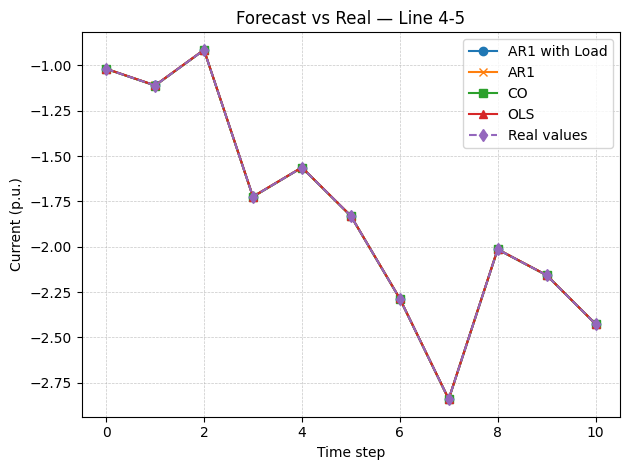

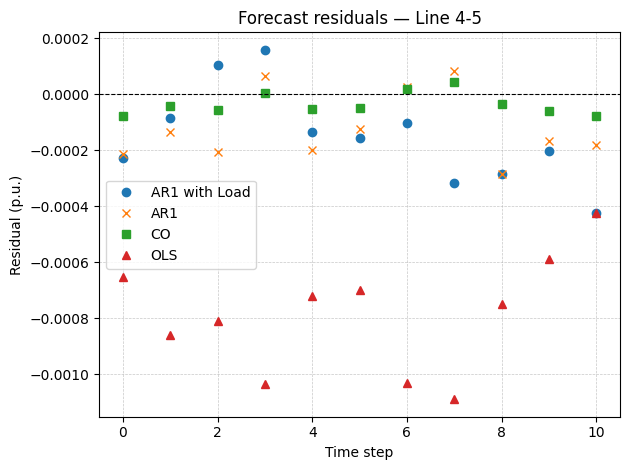

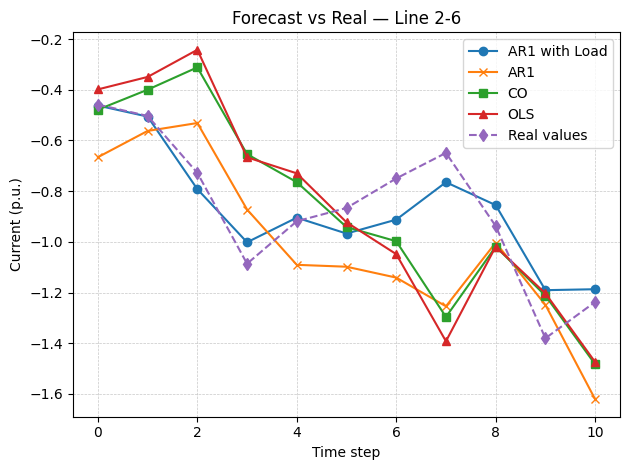

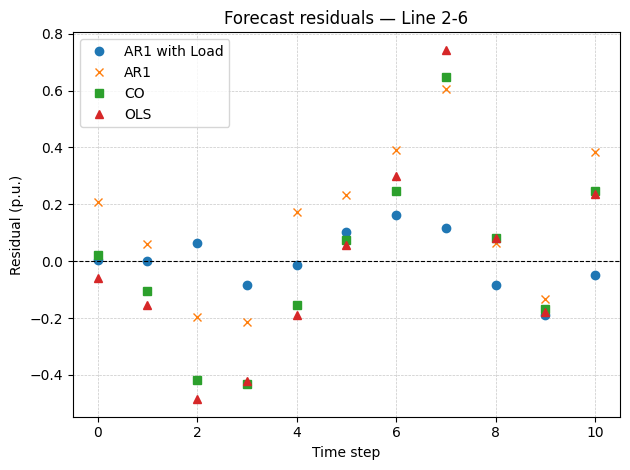

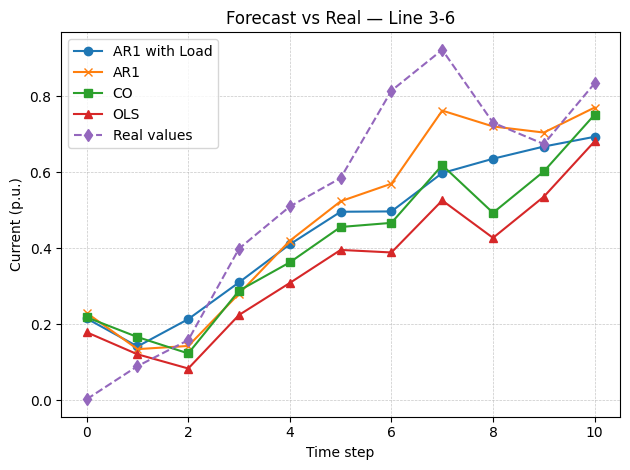

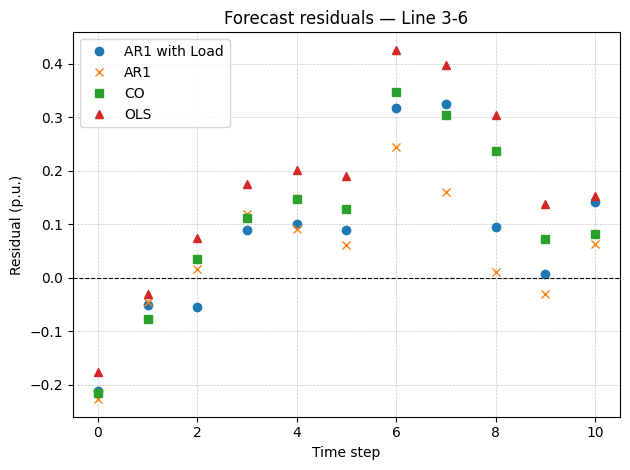

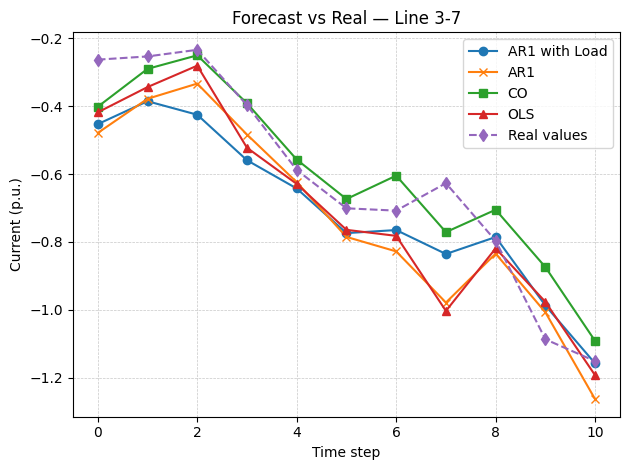

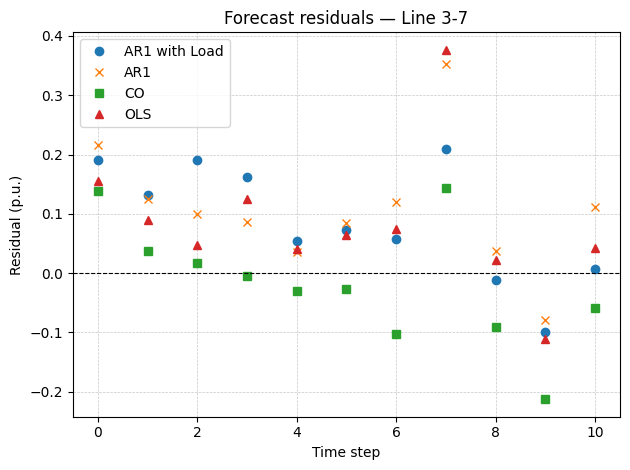

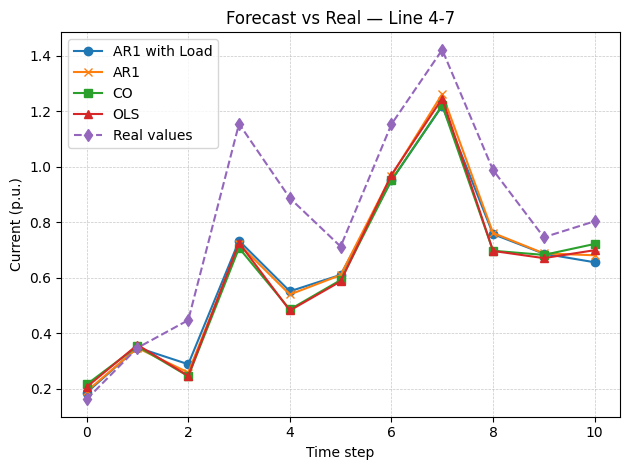

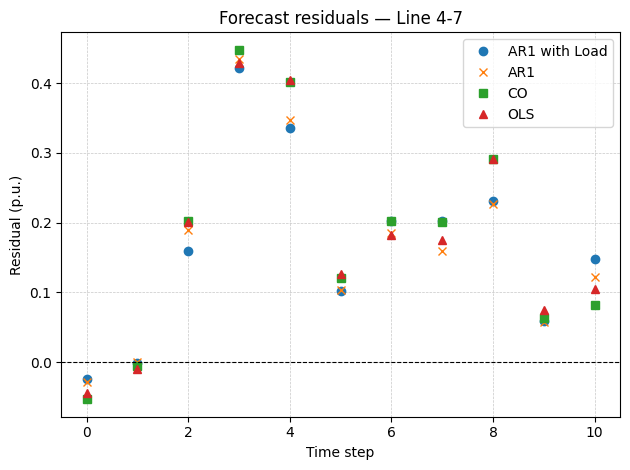

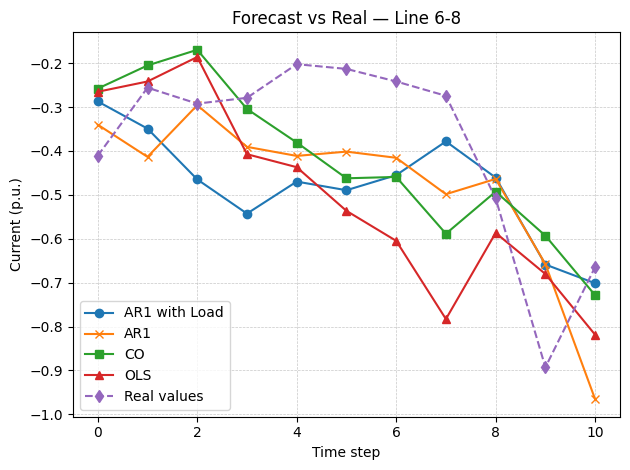

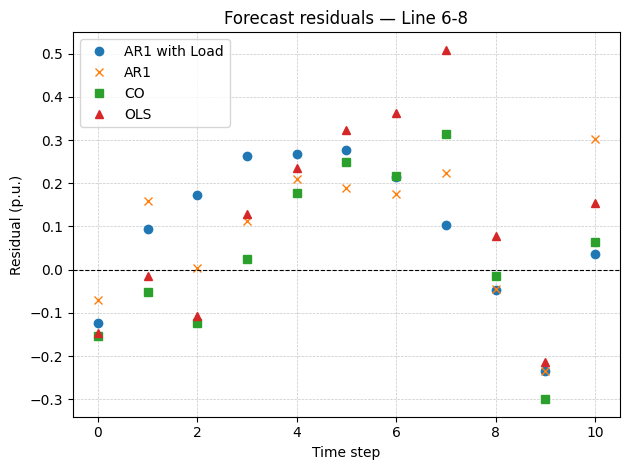

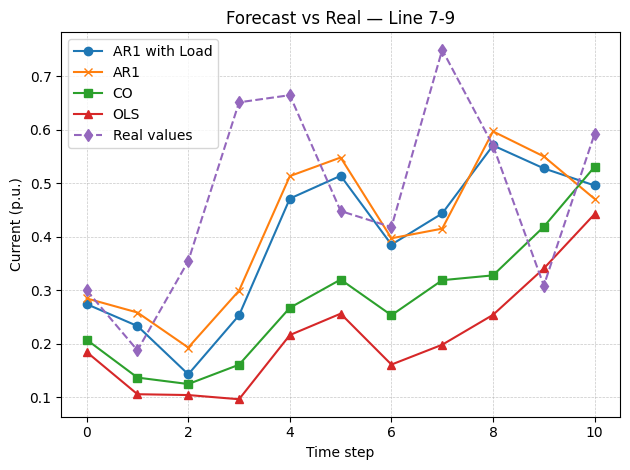

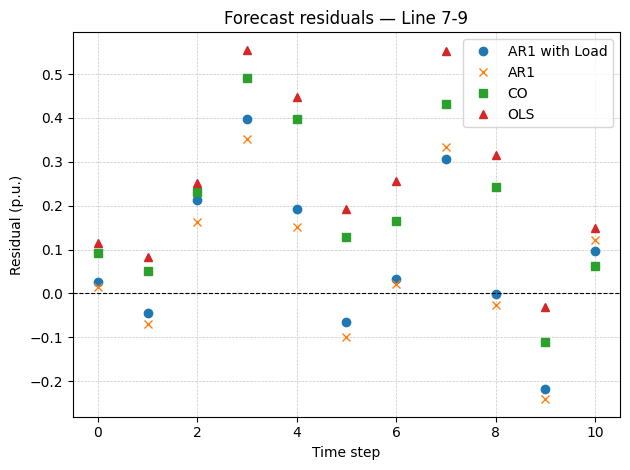

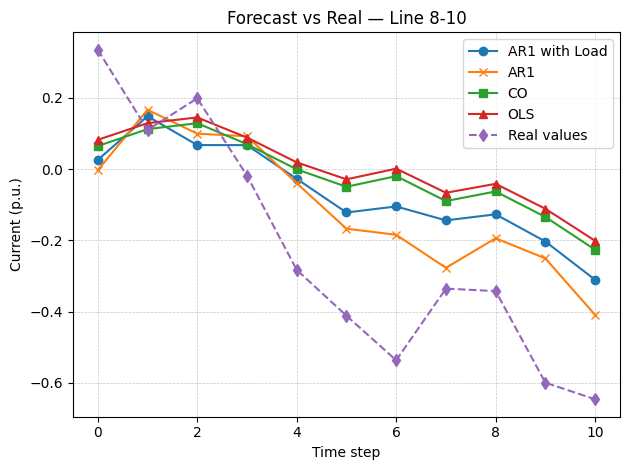

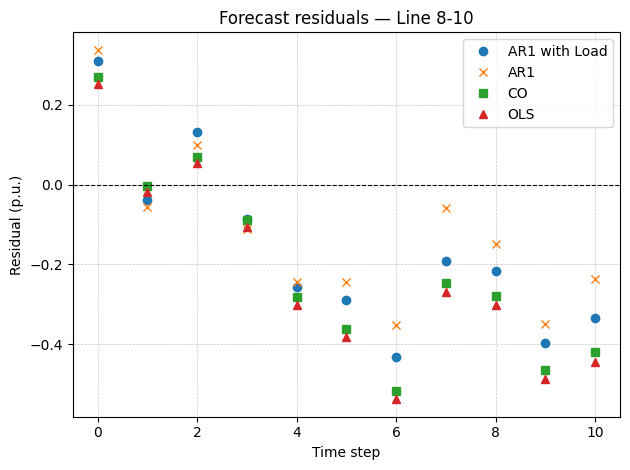

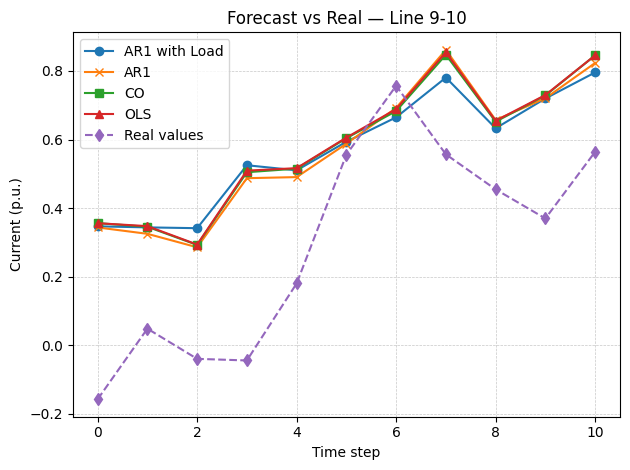

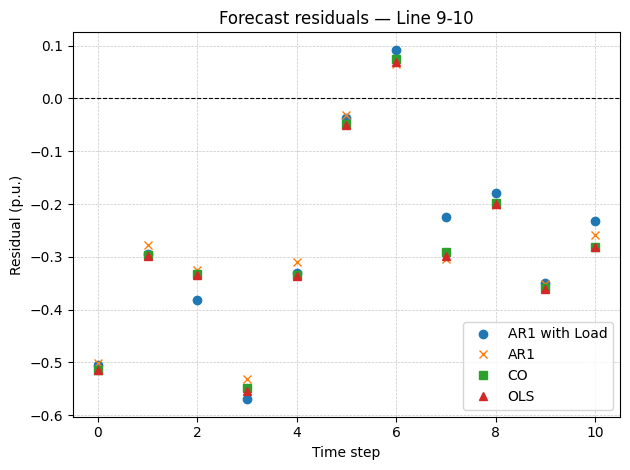

In [38]:
for k, (bi, bj) in enumerate(lines):
    iL = I_lines[k, :]
    real_values = iL[time+1:time+timeForecast]

    i_pv2_test = np.zeros(timeForecast)

    b_OLS  = beta_OLS[k]
    b_CO   = beta_CO_all[k]
    b_AR1  = beta_AR1_all[k]
    b_ARL  = beta_AR1L_all[k]

    fc_OLS = (b_OLS[0] + b_OLS[1]*i_pv1[time:time+timeForecast]
                       + b_OLS[2]*i_pv2[time:time+timeForecast])

    fc_CO  = (b_CO[0]  + b_CO[1]*i_pv1[time:time+timeForecast]
                       + b_CO[2]*i_pv2[time:time+timeForecast])

    fc_AR1 = (b_AR1[0] + b_AR1[1]*i_pv1[time+1:time+timeForecast]
                       + b_AR1[2]*i_pv2[time+1:time+timeForecast]
                       + b_AR1[3]*iL[time:time+timeForecast-1])

    fc_ARL = (b_ARL[0] + b_ARL[1]*i_pv1[time+1:time+timeForecast]
                       + b_ARL[2]*i_pv2[time+1:time+timeForecast]
                       + b_ARL[3]*iL[time:time+timeForecast-1]
                       + b_ARL[4]*load_sum[time+1:time+timeForecast])
    
    

    x = np.arange(len(fc_AR1))

    # ── Forecast plot ─────────────────────────────────────────────────────────
    plt.figure()
    plt.plot(x, fc_ARL,        label="AR1 with Load", marker='o')
    plt.plot(x, fc_AR1,        label="AR1",           marker='x')
    plt.plot(x, fc_CO[1:],     label="CO",            marker='s')
    plt.plot(x, fc_OLS[1:],    label="OLS",           marker='^')
    plt.plot(x, real_values,   label="Real values",   marker='d', linestyle='--')
    plt.xlabel("Time step")
    plt.ylabel("Current (p.u.)")
    plt.title(f"Forecast vs Real — Line {bi}-{bj}")
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()

    # ── Residuals plot ────────────────────────────────────────────────────────
    plt.figure()
    plt.plot(x, real_values - fc_ARL,     label="AR1 with Load", marker='o', linestyle='None')
    plt.plot(x, real_values - fc_AR1,     label="AR1",           marker='x', linestyle='None')
    plt.plot(x, real_values - fc_CO[1:],  label="CO",            marker='s', linestyle='None')
    plt.plot(x, real_values - fc_OLS[1:], label="OLS",           marker='^', linestyle='None')
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.xlabel("Time step")
    plt.ylabel("Residual (p.u.)")
    plt.title(f"Forecast residuals — Line {bi}-{bj}")
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()